In [1]:
import glob
import os
import re
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import pandas as pd

In [ ]:
model_names = ["MP2", "MP3", "MP4", "BN2", "BN3", "BN4", "StrideConv4"]
num_of_latent_features = [2, 20]

loss_dir = "losses/MS_all_models"
base_dir = "training_results/CD38/all_models"

In [3]:
def parse_loss_file(filename):
    """
    Parse a single loss file with lines like:
      "Epoch 0: Total Loss 213967.447097, Recon Loss 213961.755306, KL Loss 5.692201"
    Returns:
      epochs, total_losses, recon_losses, kl_losses (all lists of floats).
    """
    epochs = []
    total_losses = []
    recon_losses = []
    kl_losses = []
    
    with open(filename, "r") as f:
        for line in f:
            # Use a regex to extract the numbers
            match = re.search(
                r"Epoch\s+(\d+).*Total\s+Loss\s+([\d.]+).*Recon\s+Loss\s+([\d.]+).*KL\s+Loss\s+([\d.]+)",
                line
            )
            if match:
                epoch_str, total_str, recon_str, kl_str = match.groups()
                epochs.append(int(epoch_str))
                total_losses.append(float(total_str))
                recon_losses.append(float(recon_str))
                kl_losses.append(float(kl_str))
    return epochs, total_losses, recon_losses, kl_losses


def parse_all_loss_files(loss_dir, models, latent_dims):
    """
    Parse all combination of (model, latent_dim) within 'loss_dir' 
    using the naming pattern: 
        {model}_4000epoch_latent{latent_dim}.txt
    
    Returns a dictionary of the form:
       data[(model, dim)] = {
         'epochs': [ ... ],
         'total':  [ ... ],
         'recon':  [ ... ],
         'kl':     [ ... ],
       }
    """
    data = {}
    for model in models:
        for dim in latent_dims:
            filename = os.path.join(loss_dir, f"{model}_4000epoch_latent{dim}.txt")
            if not os.path.isfile(filename):
                print(f"WARNING: File not found: {filename}")
                continue
            epochs, total, recon, kl = parse_loss_file(filename)
            data[(model, dim)] = {
                'epochs': epochs,
                'total': total,
                'recon': recon,
                'kl': kl
            }
    return data


# Observing both latent spaces:

In [4]:
results = []

for model in model_names:
    for latent_dim in num_of_latent_features:
        # Construct filename like "MP2_4000epoch_latent2.txt"
        filename = f"losses/{model}_4000epoch_latent{latent_dim}.txt"
        
        with open(filename, "r") as f:
            lines = f.readlines()
        
        # We'll assume each line looks like:
        # Epoch 0: Total Loss 213967.447097, Recon Loss 213961.755306, KL Loss 5.692201
        # or something similar.
        
        min_total = float("inf")
        min_recon = float("inf")
        min_kl = float("inf")
        final_total = None
        final_recon = None
        final_kl = None
        
        for line in lines:
            # Split the line and parse the floats
            # This is just one naive way (you might use regex or more robust parsing)
            # Example line: 
            # "Epoch 0: Total Loss 213967.447097, Recon Loss 213961.755306, KL Loss 5.692201"
            
            parts = line.strip().split(',')
            # parts[0] = "Epoch 0: Total Loss 213967.447097"
            # parts[1] = " Recon Loss 213961.755306"
            # parts[2] = " KL Loss 5.692201"
            
            total_str = parts[0].split("Total Loss")[-1].strip()
            recon_str = parts[1].split("Recon Loss")[-1].strip()
            kl_str = parts[2].split("KL Loss")[-1].strip()
            
            total_val = float(total_str)
            recon_val = float(recon_str)
            kl_val = float(kl_str)
            
            # Track min
            if total_val < min_total:
                min_total = total_val
            if recon_val < min_recon:
                min_recon = recon_val
            if kl_val < min_kl:
                min_kl = kl_val
            
            final_total = total_val
            final_recon = recon_val
            final_kl = kl_val
        
        # Suppose we only care about the final epoch's losses (not the global min)
        results.append({
            'model': model,
            'latent': latent_dim,
            'final_total': final_total,
            'final_recon': final_recon,
            'final_kl': final_kl,
            'min_total': min_total,
            'min_recon': min_recon,
            'min_kl': min_kl
        })

# Now pick the best by final loss or min across all epochs
best_final_total = min(results, key=lambda x: x['final_total'])
best_final_recon = min(results, key=lambda x: x['final_recon'])
best_final_kl = min(results, key=lambda x: x['final_kl'])

print("Smallest final total loss:")
print(best_final_total)
print("Smallest final reconstruction loss:")
print(best_final_recon)
print("Smallest final KL divergence loss:")
print(best_final_kl)



FileNotFoundError: [Errno 2] No such file or directory: 'losses/StrideConv4_4000epoch_latent2.txt'

# Observing latent space with 2 features:

In [ ]:
results = []

for model in model_names:
    for latent_dim in [2]:
        # Construct filename like "MP2_4000epoch_latent2.txt"
        filename = f"losses/{model}_4000epoch_latent{latent_dim}.txt"
        
        with open(filename, "r") as f:
            lines = f.readlines()
        
        # We'll assume each line looks like:
        # Epoch 0: Total Loss 213967.447097, Recon Loss 213961.755306, KL Loss 5.692201
        # or something similar.
        
        min_total = float("inf")
        min_recon = float("inf")
        min_kl = float("inf")
        final_total = None
        final_recon = None
        final_kl = None
        
        for line in lines:
            # Split the line and parse the floats
            # This is just one naive way (you might use regex or more robust parsing)
            # Example line: 
            # "Epoch 0: Total Loss 213967.447097, Recon Loss 213961.755306, KL Loss 5.692201"
            
            parts = line.strip().split(',')
            # parts[0] = "Epoch 0: Total Loss 213967.447097"
            # parts[1] = " Recon Loss 213961.755306"
            # parts[2] = " KL Loss 5.692201"
            
            total_str = parts[0].split("Total Loss")[-1].strip()
            recon_str = parts[1].split("Recon Loss")[-1].strip()
            kl_str = parts[2].split("KL Loss")[-1].strip()
            
            total_val = float(total_str)
            recon_val = float(recon_str)
            kl_val = float(kl_str)
            
            # Track min
            if total_val < min_total:
                min_total = total_val
            if recon_val < min_recon:
                min_recon = recon_val
            if kl_val < min_kl:
                min_kl = kl_val
            
            final_total = total_val
            final_recon = recon_val
            final_kl = kl_val
        
        # Suppose we only care about the final epoch's losses (not the global min)
        results.append({
            'model': model,
            'latent': latent_dim,
            'final_total': final_total,
            'final_recon': final_recon,
            'final_kl': final_kl,
            'min_total': min_total,
            'min_recon': min_recon,
            'min_kl': min_kl
        })

# Now pick the best by final loss or min across all epochs
best_final_total = min(results, key=lambda x: x['final_total'])
best_final_recon = min(results, key=lambda x: x['final_recon'])
best_final_kl = min(results, key=lambda x: x['final_kl'])

print("Smallest final total loss:")
print(best_final_total)
print("Smallest final reconstruction loss:")
print(best_final_recon)
print("Smallest final KL divergence loss:")
print(best_final_kl)



Smallest final total loss:
{'model': 'MP4', 'latent': 2, 'final_total': 5699.079188, 'final_recon': 5685.843472, 'final_kl': 13.235724, 'min_total': 5682.522411, 'min_recon': 5669.261492, 'min_kl': 7.156944}
Smallest final reconstruction loss:
{'model': 'MP4', 'latent': 2, 'final_total': 5699.079188, 'final_recon': 5685.843472, 'final_kl': 13.235724, 'min_total': 5682.522411, 'min_recon': 5669.261492, 'min_kl': 7.156944}
Smallest final KL divergence loss:
{'model': 'StridedConv4', 'latent': 2, 'final_total': 7528.952072, 'final_recon': 7516.200214, 'final_kl': 12.751867, 'min_total': 7524.730508, 'min_recon': 7511.988257, 'min_kl': 12.560481}


# Plots:

In [5]:
def plot_total_loss_per_latent(data, models, latent_dims):
    """
    For each latent dimension:
      1) Plot total-loss curves (epochs >= 500) for all models.
      2) Display a text box on the right side listing each model's 
         final-epoch total loss in DESCENDING order.
    """
    for dim in latent_dims:
        # Create a new figure and axes
        fig, ax = plt.subplots()
        
        # We'll collect final-loss info here
        final_vals = []  # list of (model, final_epoch, final_total_loss)
        
        for model in models:
            # Skip if this (model, dim) isn't in the data dictionary
            if (model, dim) not in data:
                continue
            
            content = data[(model, dim)]
            epochs = content['epochs']
            total_losses = content['total']
            
            # --- 1) Slicing out epochs < 500 ---
            start_idx = None
            for i, ep in enumerate(epochs):
                if ep >= 500:
                    start_idx = i
                    break
            if start_idx is None:
                # No epochs >= 500; skip
                continue
            
            ep_slice = epochs[start_idx:]
            tot_slice = total_losses[start_idx:]
            
            # Plot each model’s curve
            ax.plot(ep_slice, tot_slice, label=model)

            # --- 2) Store final-epoch info for this model ---
            # We’ll use the very last epoch in the file (whatever it is).
            final_epoch = epochs[-1]
            final_total = total_losses[-1]
            final_vals.append((model, final_epoch, final_total))
        
        # Sort the final values by total loss in descending order
        final_vals.sort(key=lambda x: x[2], reverse=True)
        
        # Build a multiline string showing each model in descending order
        # Format: "Model: 1234.56 (ep=XXXX)"
        text_lines = [
            f"{m}: {val:.2f} (epoch={ep})"
            for (m, ep, val) in final_vals
        ]
        big_text = "\n".join(text_lines)
        
        # Position the text box on the right
        # We'll shift the plot's right edge inward so there's room for the text
        plt.subplots_adjust(right=0.7)  # leave space on the right
        ax.text(
            1.02, 0.5, big_text,
            transform=ax.transAxes,     # place relative to axes
            va='center',               # vertical alignment to center
        )
        
        # Label and title
        ax.set_xlabel("Epoch (≥ 500)")
        ax.set_ylabel("Total Loss")
        ax.set_title(f"All Models (latent={dim}) — Final Loss in Descending Order")
        
        # Optionally show a legend of lines (but not strictly needed
        # since we have the text box). You can comment this out if you like.
        ax.legend()
        
        plt.show()


In [6]:
def plot_all_losses_after_500_by_dim(data, latent_dims=[2, 20]):
    """
    Creates 6 total plots if you have exactly 2 latent dimensions (2, 20):
      - For latent=2: 
          1) total-loss curves 
          2) recon-loss curves 
          3) KL-loss curves
      - For latent=20:
          4) total-loss curves
          5) recon-loss curves
          6) KL-loss curves
          
    Each plot shows one line per model in that latent dimension,
    only epochs >= 500 are included, AND a text box on the right
    shows final-epoch losses in descending order.
    """
    for dim in latent_dims:
        # ----------------------
        # 1) TOTAL LOSS PLOT
        # ----------------------
        plt.figure()
        
        final_vals_total = []  # will hold (model, final_epoch, final_total)
        
        for (model, d), content in data.items():
            # Skip if not for the current latent dimension
            if d != dim:
                continue
            
            epochs = content['epochs']
            total_losses = content['total']
            
            # Find first epoch >= 500
            start_idx = next((i for i, ep in enumerate(epochs) if ep >= 500), None)
            if start_idx is not None:
                ep_slice = epochs[start_idx:]
                total_slice = total_losses[start_idx:]
                plt.plot(ep_slice, total_slice, label=f"{model} (lat={d})")
            
            # Record final-epoch total from the entire file (not just after 500)
            if len(epochs) > 0:
                final_epoch = epochs[-1]
                final_total = total_losses[-1]
                final_vals_total.append((model, final_epoch, final_total))
        
        # Sort final-epoch total in descending order
        final_vals_total.sort(key=lambda x: x[2], reverse=True)
        
        # Build a multi-line string
        lines_total = [
            f"{m}: {val:.2f} (ep={ep})"
            for (m, ep, val) in final_vals_total
        ]
        text_total = "\n".join(lines_total)
        
        # Shift the plot to make room on the right
        plt.subplots_adjust(right=0.7)
        
        # Place text box on the right side
        plt.text(
            1.02, 0.5, text_total,
            transform=plt.gca().transAxes,
            va='center',
            ha='left',
            bbox=dict(facecolor='white', alpha=0.8)
        )
        
        plt.xlabel("Epoch (≥ 500)")
        plt.ylabel("Total Loss")
        plt.title(f"All Models (latent={dim}) - Total Loss (Epoch ≥ 500)")
        plt.legend()
        plt.show()
        
        # ----------------------
        # 2) RECON LOSS PLOT
        # ----------------------
        plt.figure()
        
        final_vals_recon = []  # (model, final_epoch, final_recon)
        
        for (model, d), content in data.items():
            if d != dim:
                continue
            
            epochs = content['epochs']
            recon_losses = content['recon']
            
            start_idx = next((i for i, ep in enumerate(epochs) if ep >= 500), None)
            if start_idx is not None:
                ep_slice = epochs[start_idx:]
                recon_slice = recon_losses[start_idx:]
                plt.plot(ep_slice, recon_slice, label=f"{model} (lat={d})")
            
            # Store final-epoch recon from the entire file
            if len(epochs) > 0:
                final_epoch = epochs[-1]
                final_recon = recon_losses[-1]
                final_vals_recon.append((model, final_epoch, final_recon))
        
        # Sort by final recon in descending order
        final_vals_recon.sort(key=lambda x: x[2], reverse=True)
        
        # Build multiline string
        lines_recon = [
            f"{m}: {val:.2f} (ep={ep})"
            for (m, ep, val) in final_vals_recon
        ]
        text_recon = "\n".join(lines_recon)
        
        plt.subplots_adjust(right=0.7)
        plt.text(
            1.02, 0.5, text_recon,
            transform=plt.gca().transAxes,
            va='center',
            ha='left',
            bbox=dict(facecolor='white', alpha=0.8)
        )
        
        plt.xlabel("Epoch (≥ 500)")
        plt.ylabel("Recon Loss")
        plt.title(f"All Models (latent={dim}) - Recon Loss (Epoch ≥ 500)")
        plt.legend()
        plt.show()
        
        # ----------------------
        # 3) KL LOSS PLOT
        # ----------------------
        plt.figure()
        
        final_vals_kl = []  # (model, final_epoch, final_kl)
        
        for (model, d), content in data.items():
            if d != dim:
                continue
            
            epochs = content['epochs']
            kl_losses = content['kl']
            
            start_idx = next((i for i, ep in enumerate(epochs) if ep >= 500), None)
            if start_idx is not None:
                ep_slice = epochs[start_idx:]
                kl_slice = kl_losses[start_idx:]
                plt.plot(ep_slice, kl_slice, label=f"{model} (lat={d})")
            
            # Store final-epoch KL from the entire file
            if len(epochs) > 0:
                final_epoch = epochs[-1]
                final_kl = kl_losses[-1]
                final_vals_kl.append((model, final_epoch, final_kl))
        
        # Sort final KL in descending order
        final_vals_kl.sort(key=lambda x: x[2], reverse=True)
        
        lines_kl = [
            f"{m}: {val:.2f} (ep={ep})"
            for (m, ep, val) in final_vals_kl
        ]
        text_kl = "\n".join(lines_kl)
        
        plt.subplots_adjust(right=0.7)
        plt.text(
            1.02, 0.5, text_kl,
            transform=plt.gca().transAxes,
            va='center',
            ha='left',
            bbox=dict(facecolor='white', alpha=0.8)
        )
        
        plt.xlabel("Epoch (≥ 500)")
        plt.ylabel("KL Loss")
        plt.title(f"All Models (latent={dim}) - KL Loss (Epoch ≥ 500)")
        plt.legend()
        plt.show()


In [7]:
data = parse_all_loss_files(loss_dir, model_names, num_of_latent_features)

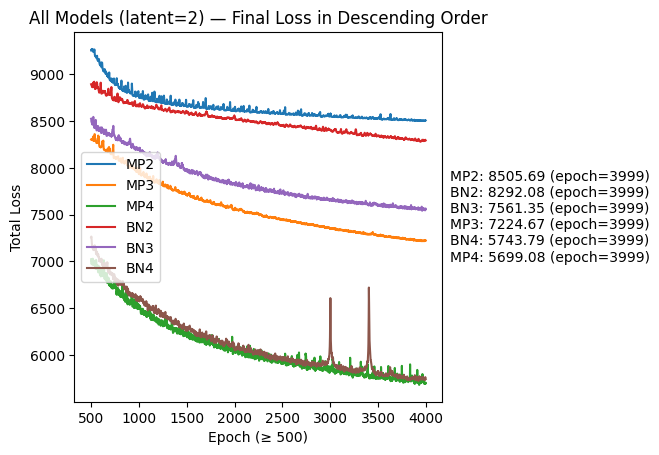

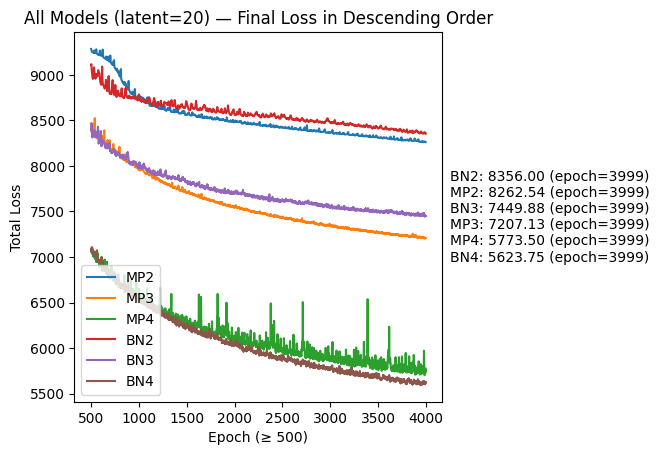

In [8]:
plot_total_loss_per_latent(data, model_names, [2, 20])

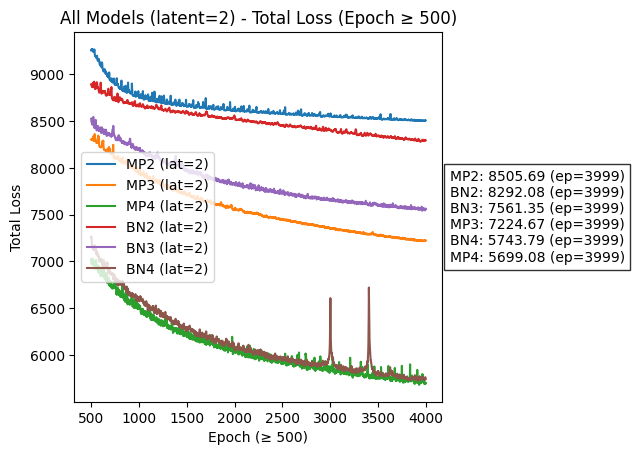

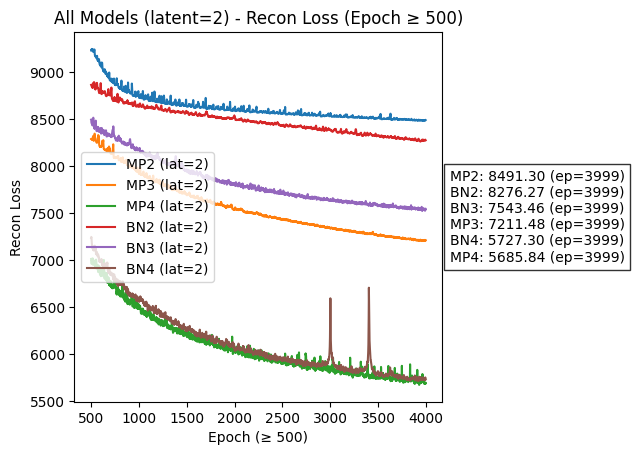

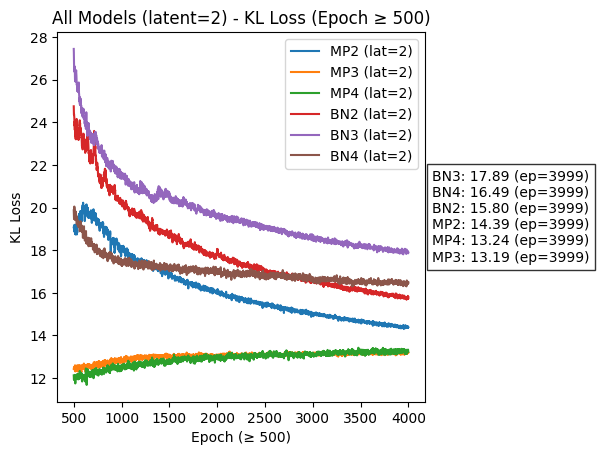

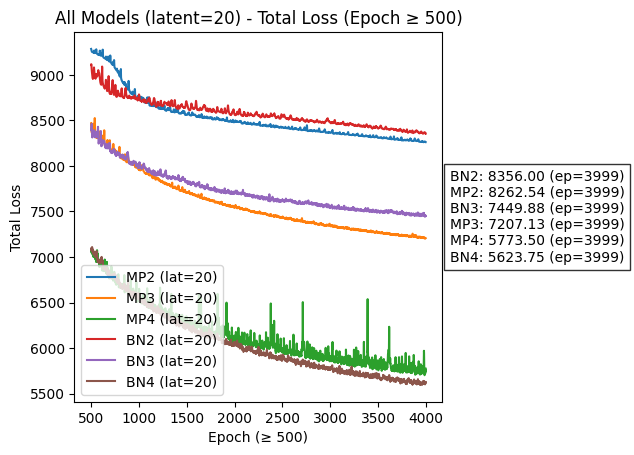

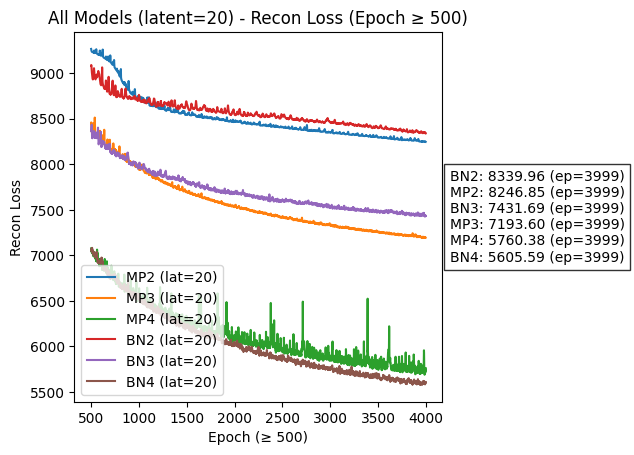

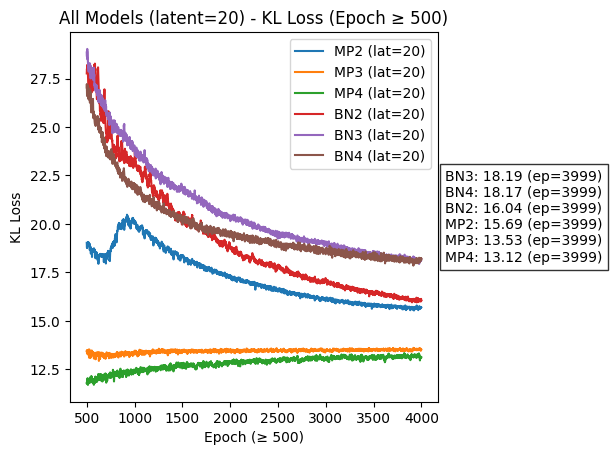

In [9]:
plot_all_losses_after_500_by_dim(data, latent_dims=[2, 20])

## Observe the latent space and latent features based on different metrics

### Silhouette Score:
Quantifies how similar each point is to points in its own cluster versus points in other clusters. It considers both cohesion (how close points in the same cluster are) and separation (how far points in different clusters are).
 
Value: between -1 and +1
- Score close to +1: well clustered and and far from neighbouring clusters
- Score near to 0: sample is on very close to the decision boundary between two neighboring clusters
- Negative values: sample might have been assigned to the wrong cluster

A high overall Silhouette Score means that the model’s latent representations naturally group similar samples together, which is desirable.

### Adjusted Rand Index (ARI):
Compares the similarity between two different clustering by considering all pairs of samples and counting pairs that are assigned in the same or different clusters in both the predicted and the true clusterings.
The ARI is a corrected-for-chance version of the Rand Index. It adjusts for the expected similarity of all pairwise assignments between clusters due to random chance.

Value: between -1 and +1
- +1 indicates perfect agreement between the clustering and the true labels
- Score 0 indicates random clustering (no better chance)
- Negative values indicates less agreement than expected by chance

Especially valuable when you want to compare how well the clusters discovered by an unsupervised method (like K-Means) match the true labels. A high ARI means that the latent space is organized in a way that reflects the true grouping of the data.

### Classification Accuracy (via Logistic Regression):
How well a simple classifier (logistic regression) can predict the provided labels based on the latent representations. The latent features are used as input to the logistic regression model. Cross-validation (e.g., 5-fold CV) is applied to estimate the prediction accuracy robustly. Essentially, if the latent space contains strong, discriminative information about the labels, the classifier will achieve high accuracy.

Value: fraction of correctly predicted labels
- close to 100% indicates that tha latent representations are highly informative and well separated according to the labels
- lower accuracy means that the latent space does not clearly distinguish between different classes


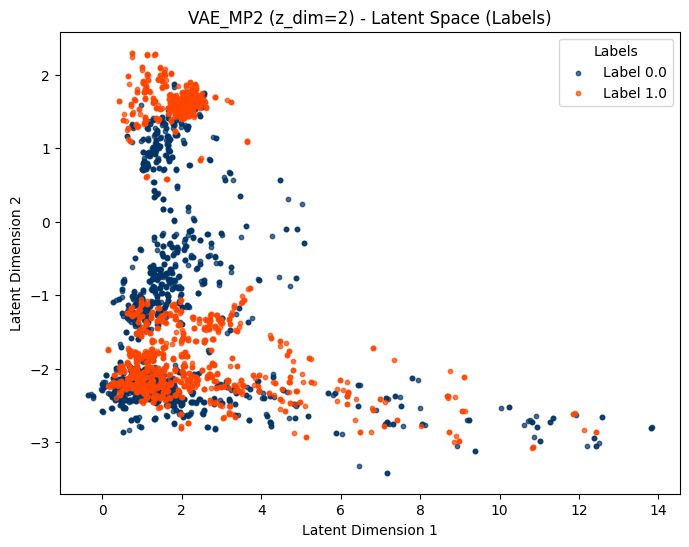

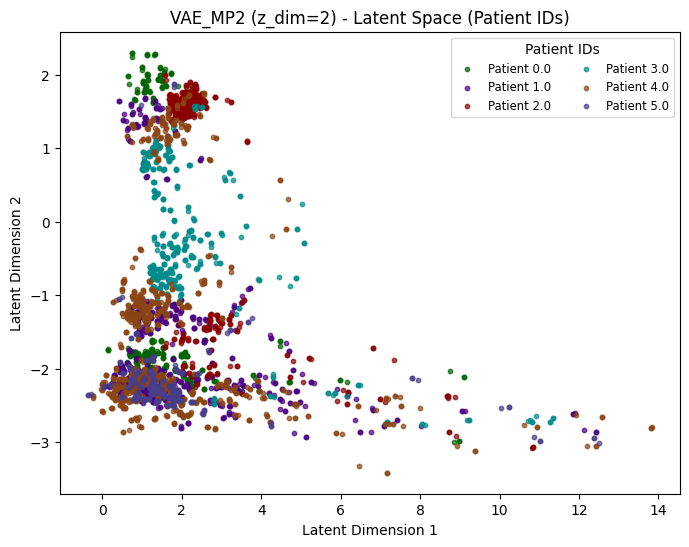

VAE_MP2 (z_dim=2) Silhouette Score: 0.0330
VAE_MP2 (z_dim=2) Adjusted Rand Index (ARI): -0.0001
VAE_MP2 (z_dim=2) Classification Accuracy: 0.5187
------------------------------------------------------------


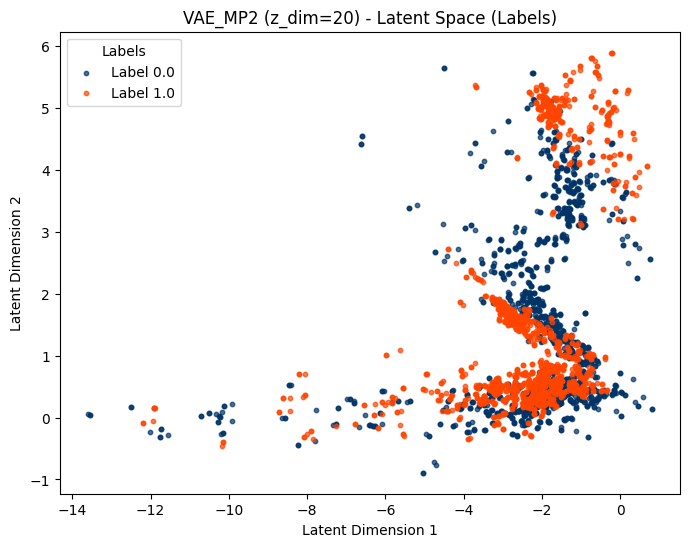

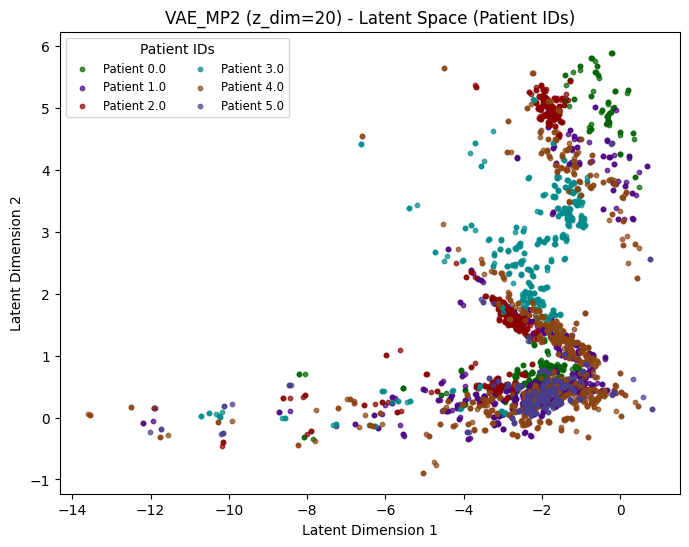

VAE_MP2 (z_dim=20) Silhouette Score: 0.0203
VAE_MP2 (z_dim=20) Adjusted Rand Index (ARI): 0.0000
VAE_MP2 (z_dim=20) Classification Accuracy: 0.5387
------------------------------------------------------------


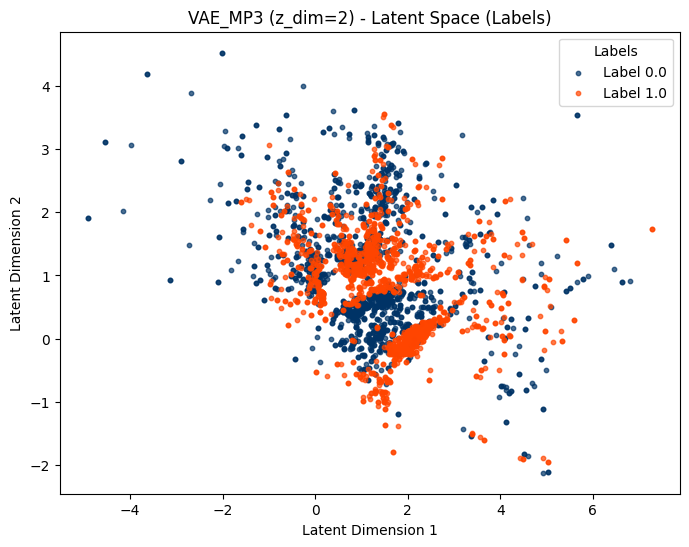

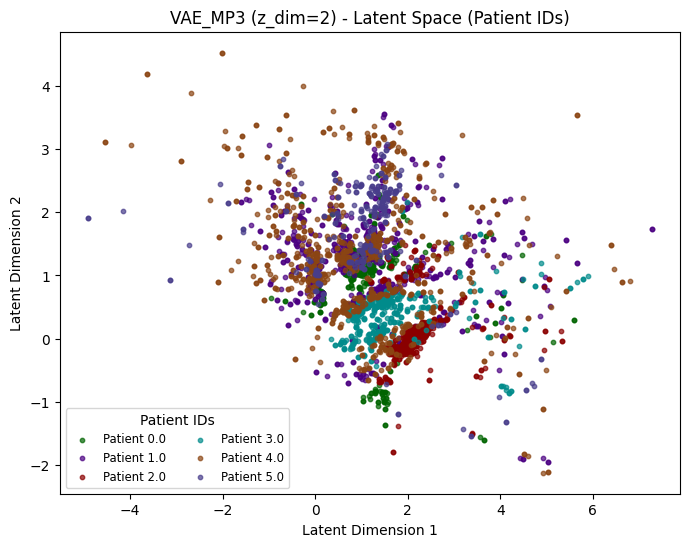

VAE_MP3 (z_dim=2) Silhouette Score: 0.0327
VAE_MP3 (z_dim=2) Adjusted Rand Index (ARI): 0.0273
VAE_MP3 (z_dim=2) Classification Accuracy: 0.5334
------------------------------------------------------------


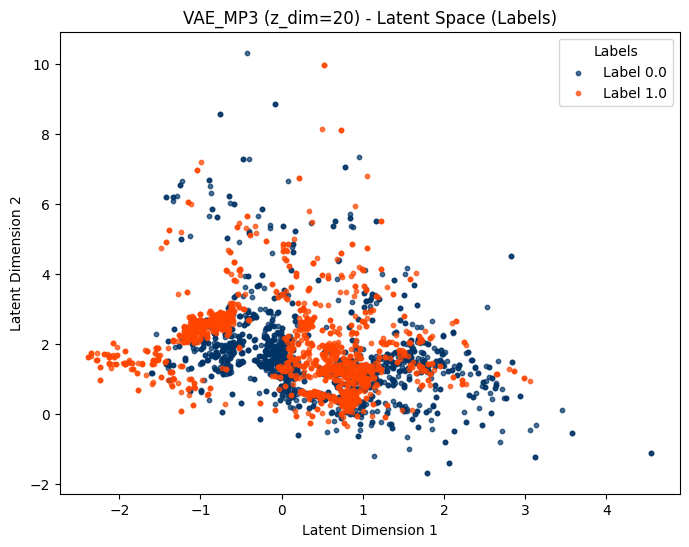

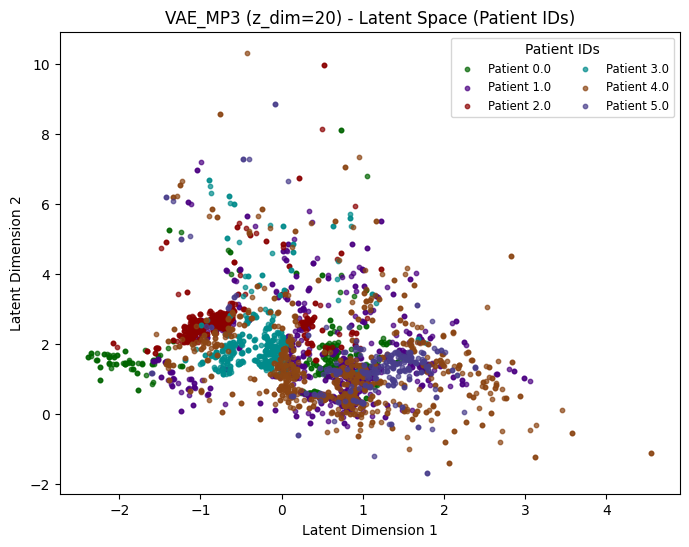

VAE_MP3 (z_dim=20) Silhouette Score: 0.0353
VAE_MP3 (z_dim=20) Adjusted Rand Index (ARI): 0.0214
VAE_MP3 (z_dim=20) Classification Accuracy: 0.5378
------------------------------------------------------------


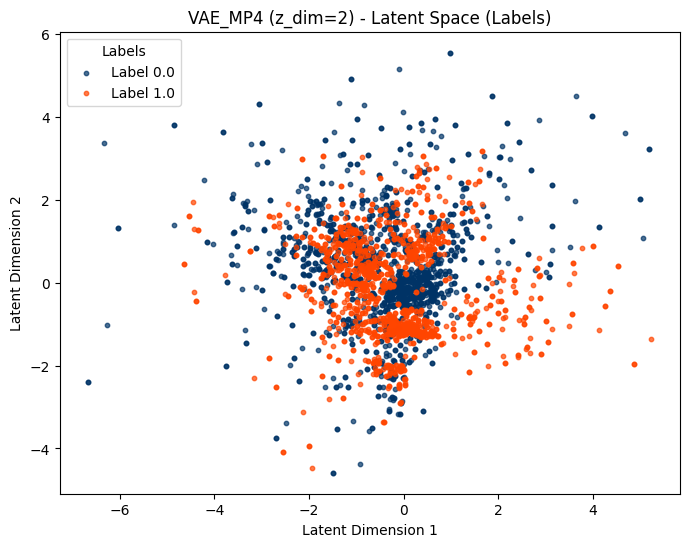

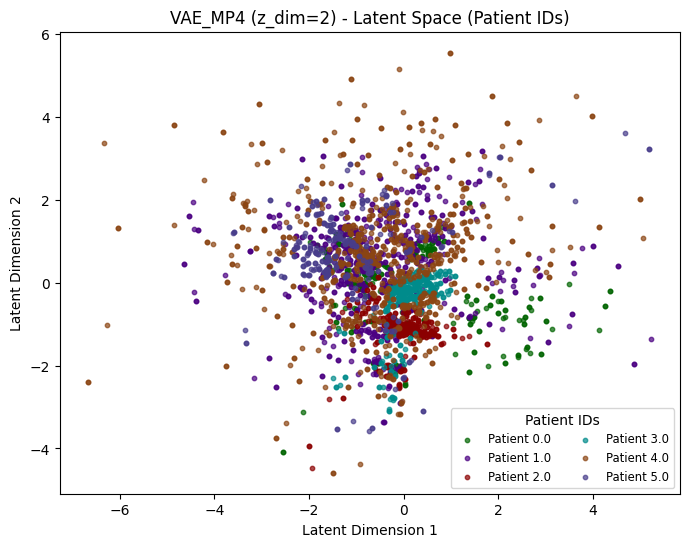

VAE_MP4 (z_dim=2) Silhouette Score: 0.0444
VAE_MP4 (z_dim=2) Adjusted Rand Index (ARI): 0.0104
VAE_MP4 (z_dim=2) Classification Accuracy: 0.5621
------------------------------------------------------------


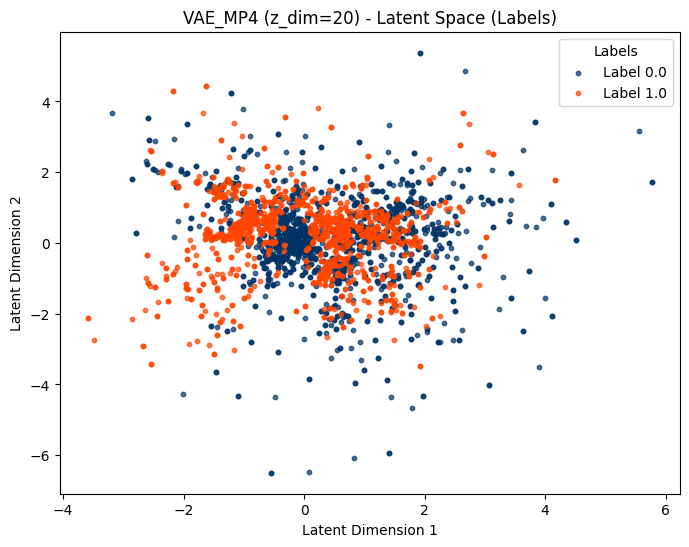

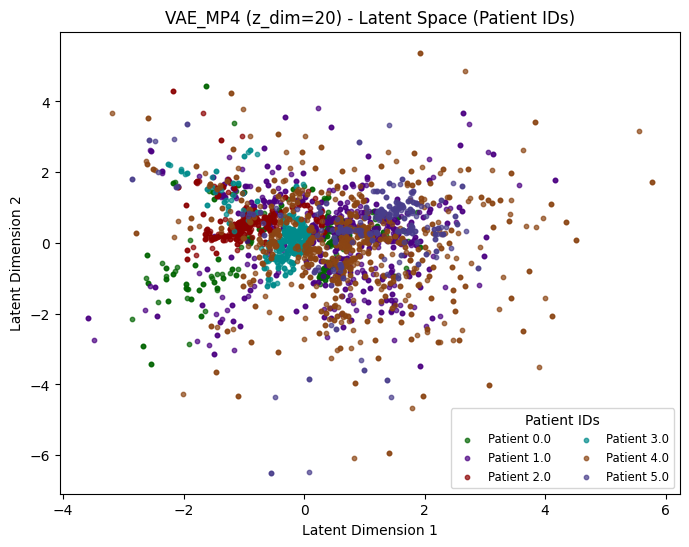

VAE_MP4 (z_dim=20) Silhouette Score: 0.0472
VAE_MP4 (z_dim=20) Adjusted Rand Index (ARI): 0.0144
VAE_MP4 (z_dim=20) Classification Accuracy: 0.5596
------------------------------------------------------------


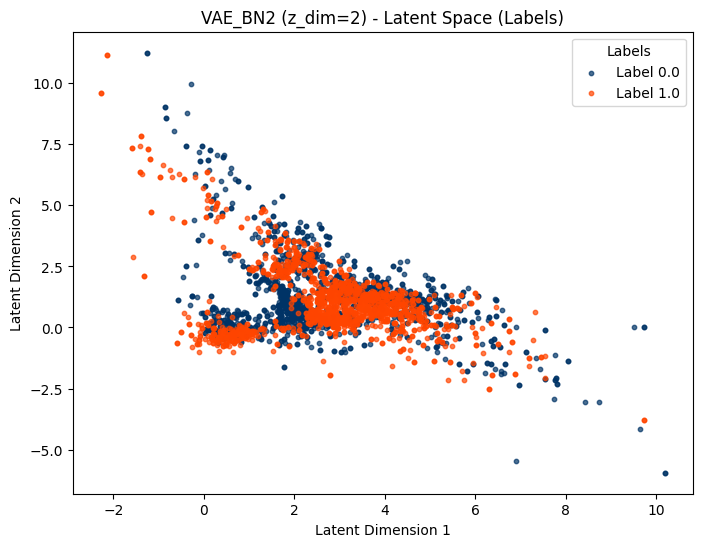

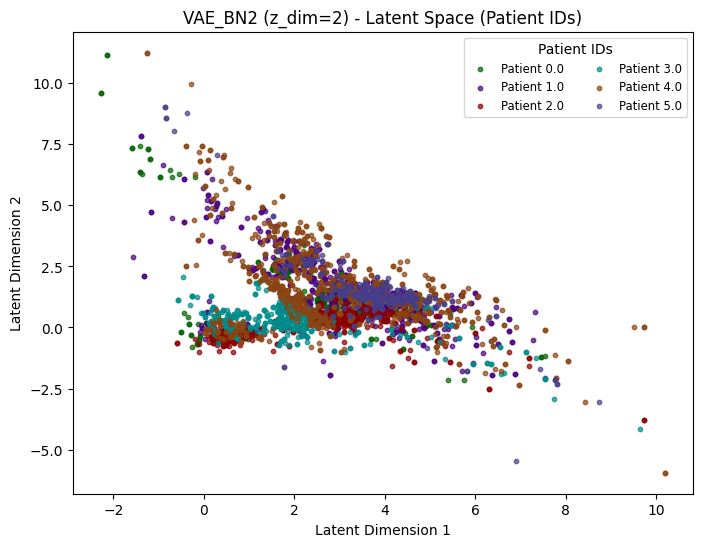

VAE_BN2 (z_dim=2) Silhouette Score: 0.0154
VAE_BN2 (z_dim=2) Adjusted Rand Index (ARI): 0.0012
VAE_BN2 (z_dim=2) Classification Accuracy: 0.5427
------------------------------------------------------------


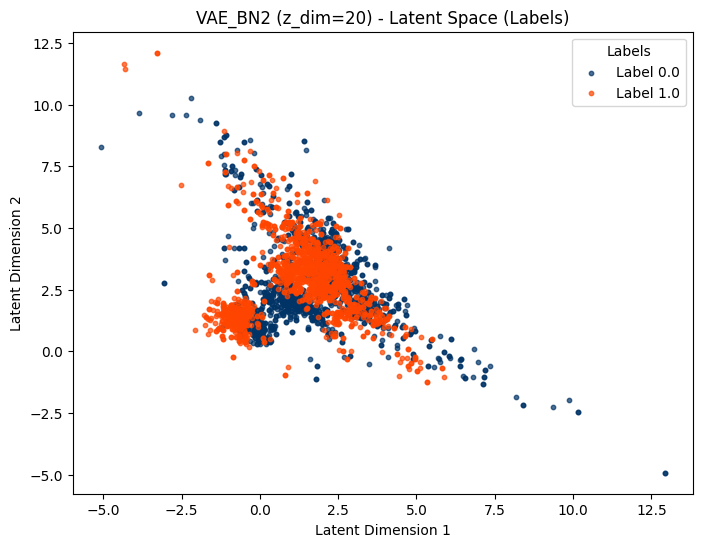

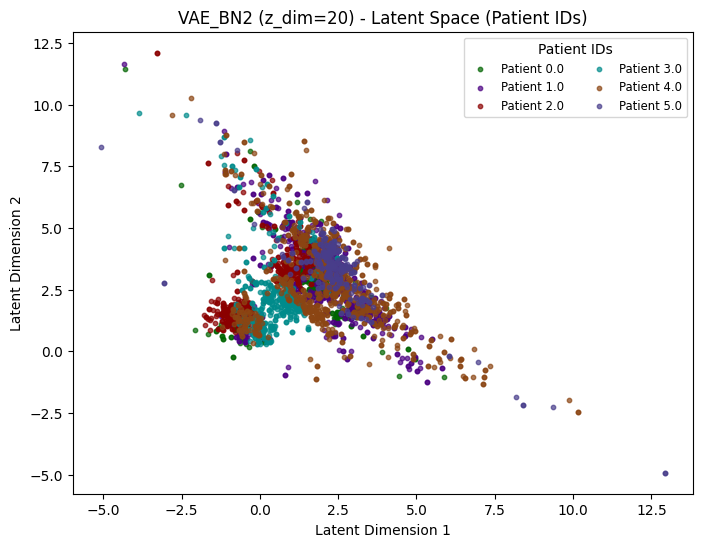

VAE_BN2 (z_dim=20) Silhouette Score: 0.0172
VAE_BN2 (z_dim=20) Adjusted Rand Index (ARI): 0.0136
VAE_BN2 (z_dim=20) Classification Accuracy: 0.5403
------------------------------------------------------------


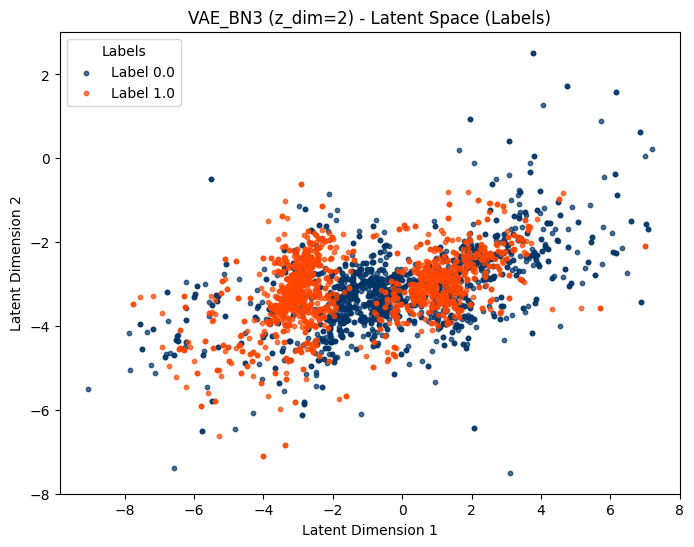

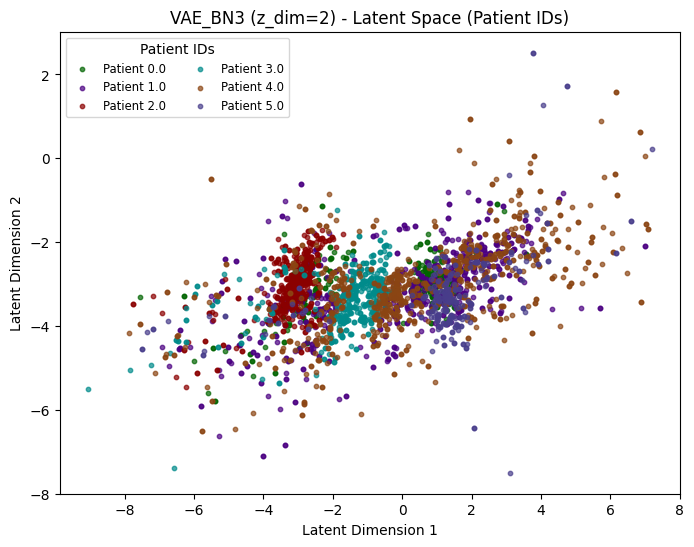

VAE_BN3 (z_dim=2) Silhouette Score: 0.0560
VAE_BN3 (z_dim=2) Adjusted Rand Index (ARI): 0.0162
VAE_BN3 (z_dim=2) Classification Accuracy: 0.5980
------------------------------------------------------------


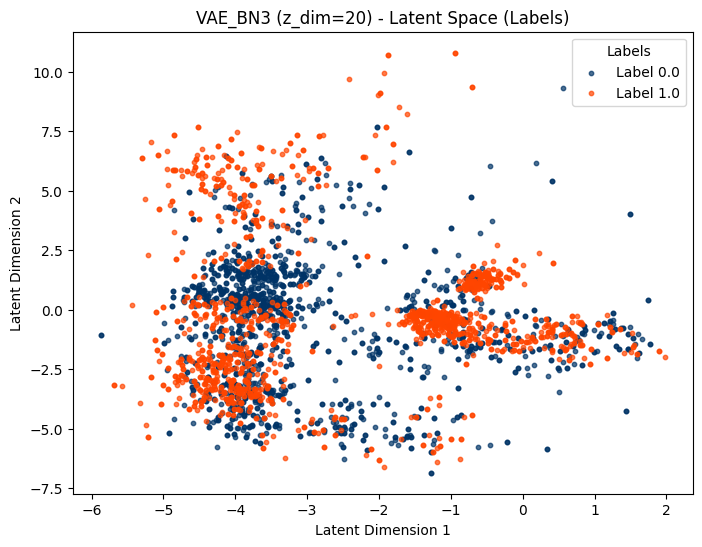

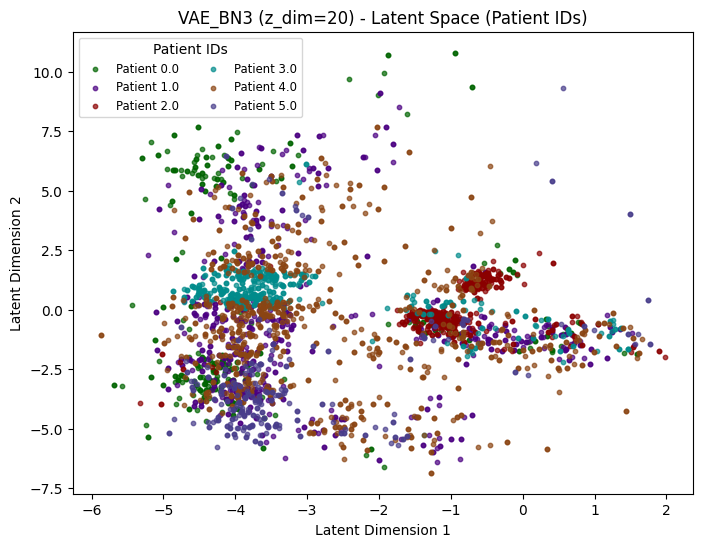

VAE_BN3 (z_dim=20) Silhouette Score: 0.0370
VAE_BN3 (z_dim=20) Adjusted Rand Index (ARI): 0.0148
VAE_BN3 (z_dim=20) Classification Accuracy: 0.6248
------------------------------------------------------------


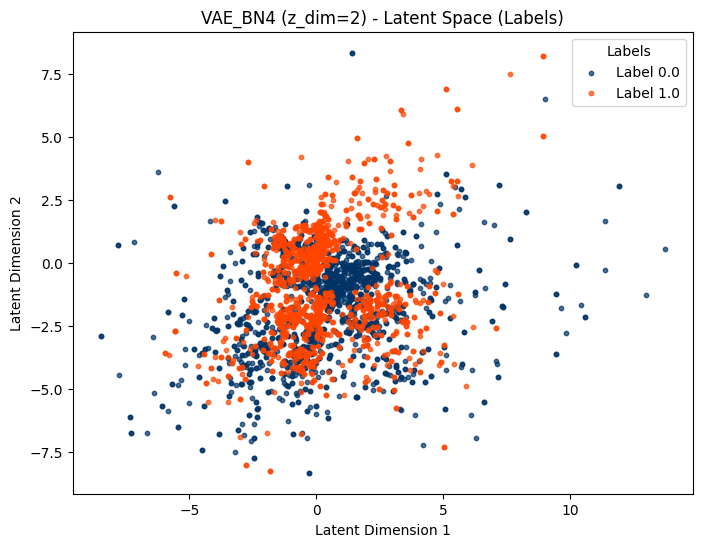

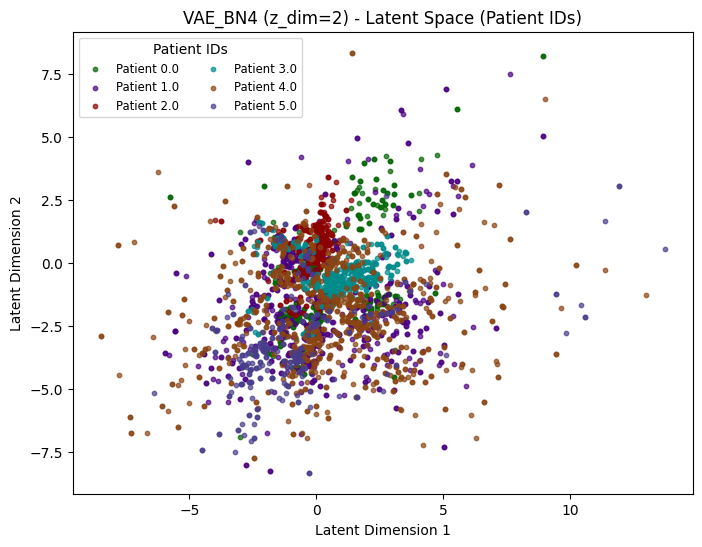

VAE_BN4 (z_dim=2) Silhouette Score: 0.0429
VAE_BN4 (z_dim=2) Adjusted Rand Index (ARI): 0.0085
VAE_BN4 (z_dim=2) Classification Accuracy: 0.5799
------------------------------------------------------------


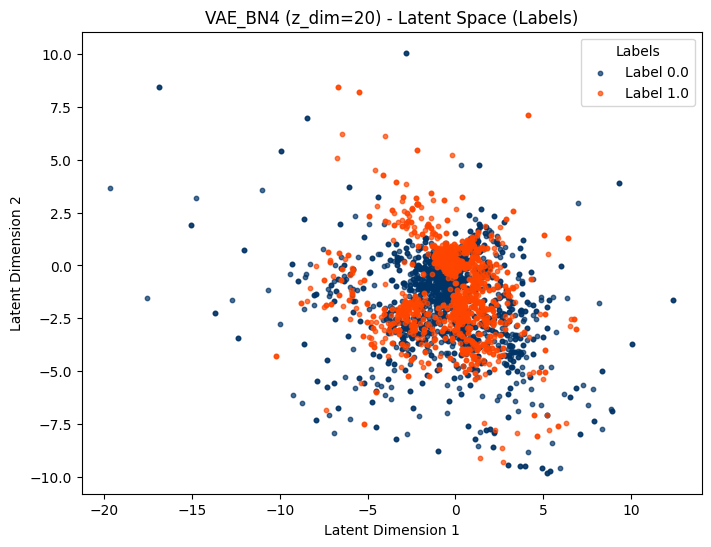

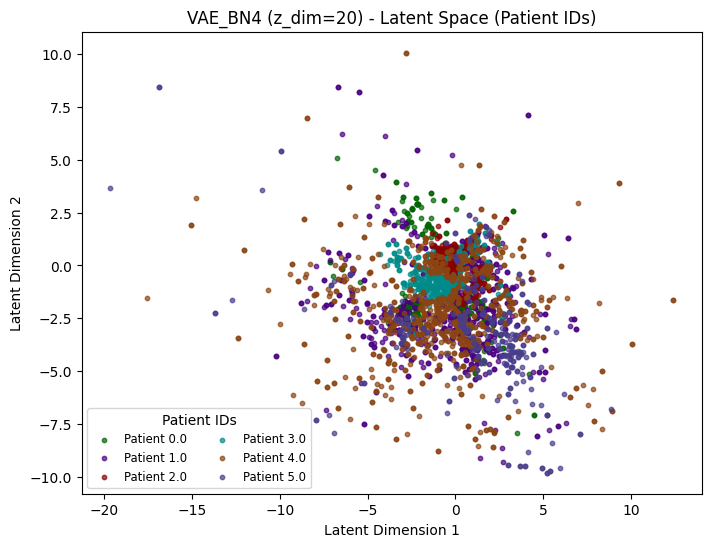

VAE_BN4 (z_dim=20) Silhouette Score: 0.0360
VAE_BN4 (z_dim=20) Adjusted Rand Index (ARI): 0.0090
VAE_BN4 (z_dim=20) Classification Accuracy: 0.5799
------------------------------------------------------------


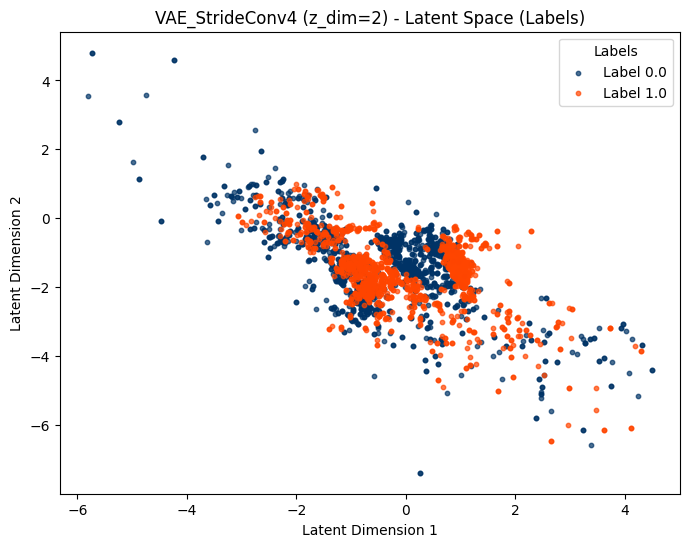

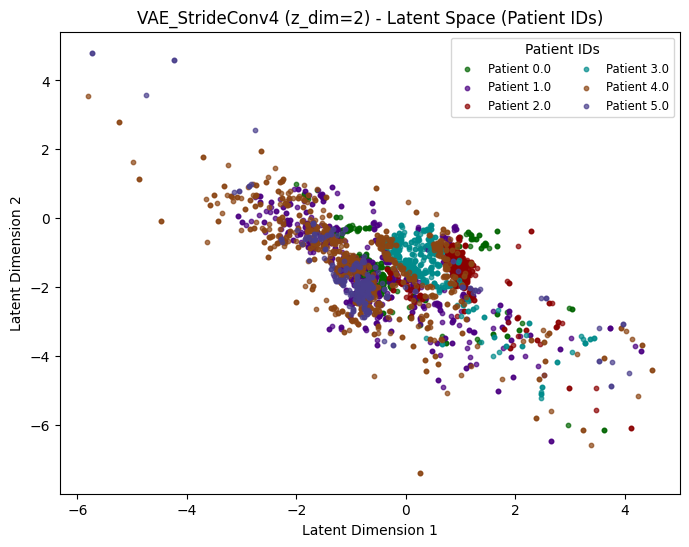

VAE_StrideConv4 (z_dim=2) Silhouette Score: 0.0294
VAE_StrideConv4 (z_dim=2) Adjusted Rand Index (ARI): 0.0296
VAE_StrideConv4 (z_dim=2) Classification Accuracy: 0.5240
------------------------------------------------------------


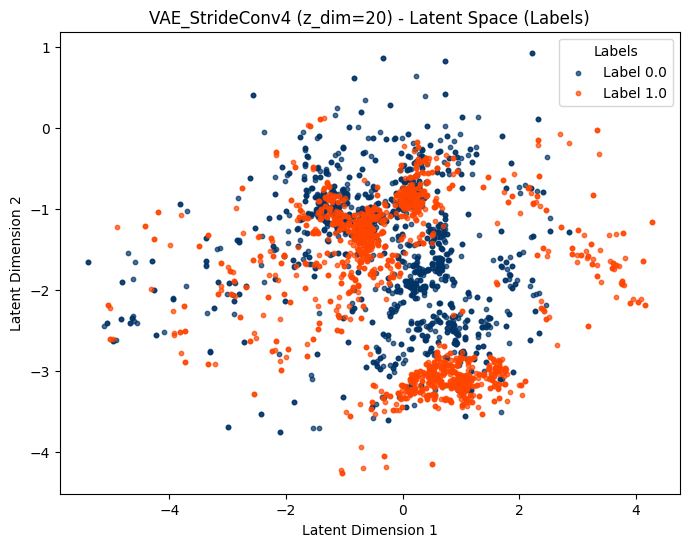

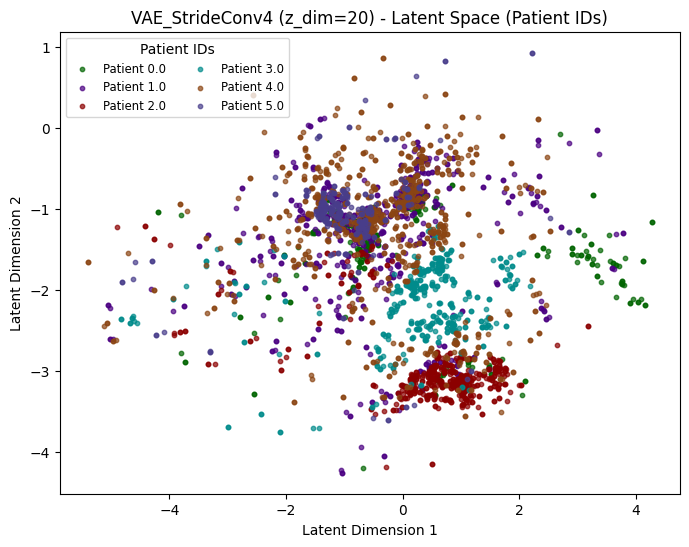

VAE_StrideConv4 (z_dim=20) Silhouette Score: 0.0351
VAE_StrideConv4 (z_dim=20) Adjusted Rand Index (ARI): 0.0018
VAE_StrideConv4 (z_dim=20) Classification Accuracy: 0.5546
------------------------------------------------------------


In [10]:
all_metrics = []

for model in model_names:
    for dim in num_of_latent_features:
        # Construct the folder name based on latent dimension.
        # e.g., "VAE_loss_mse_epochs_4000_lr_0.0001_z_dim_2_batch_size_32_beta_1"
        folder_name = f"VAE_loss_mse_epochs_4000_lr_0.0001_z_dim_{dim}_batch_size_32_beta_1"
        # Use "VAE_" prefix for each model folder.
        model_dir = os.path.join(base_dir, "VAE_" + model, folder_name)
        
        if not os.path.exists(model_dir):
            print(f"Folder not found: {model_dir}")
            continue

        # For visualization:
        # If dim==2, use the original latent file (already 2D).
        # If dim==20, use a pre-reduced 2D version (latent_reduced_train.txt).
        if dim == 2:
            latent_vis_file = os.path.join(model_dir, "latent_train.txt")
        else:
            latent_vis_file = os.path.join(model_dir, "latent_reduced_train.txt")
        
        # Files for labels and patient labels.
        labels_file = os.path.join(model_dir, "latent_train_labels.txt")
        patient_labels_file = os.path.join(model_dir, "latent_train_patient_labels.txt")
        
        # Check if all required files exist.
        if not (os.path.exists(latent_vis_file) and os.path.exists(labels_file) and os.path.exists(patient_labels_file)):
            print(f"Missing files in {model_dir}")
            continue

        # Load the latent features for visualization.
        latent_vis = np.loadtxt(latent_vis_file, delimiter=",")
        # Load the binary (or categorical) labels.
        labels = np.loadtxt(labels_file)
        # Load patient labels.
        patient_labels = np.loadtxt(patient_labels_file)
        
        # -------------------------
        # 1. Visualize the Latent Space by Labels
        # -------------------------
        # Define fixed dark colors if there are exactly 2 labels.
        unique_labels = np.unique(labels)
        if len(unique_labels) == 2:
            label_color_map = {unique_labels[0]: "#003366",  # Dark Navy Blue
                               unique_labels[1]: "#FF4500"}  # Dark Orange-Red
        else:
            # Fallback: use default colormap if not binary.
            label_color_map = {label: None for label in unique_labels}
        
        plt.figure(figsize=(8, 6))
        for label in unique_labels:
            mask = (labels == label)
            color = label_color_map[label] if label_color_map[label] is not None else None
            plt.scatter(latent_vis[mask, 0], latent_vis[mask, 1],
                        color=color, cmap=None if color is not None else 'viridis',
                        alpha=0.7, s=10, label=f"Label {label}")
        plt.xlabel("Latent Dimension 1")
        plt.ylabel("Latent Dimension 2")
        plt.title(f"VAE_{model} (z_dim={dim}) - Latent Space (Labels)")
        plt.legend(title="Labels", loc="best")
        plt.show()
        
        # -------------------------
        # 2. Visualize the Latent Space by Patient IDs
        # -------------------------
        unique_patients = np.unique(patient_labels)
        # Fixed dark color list for patients.
        patient_color_list = ["#006400", "#4B0082", "#8B0000", "#008B8B", "#8B4513", "#483D8B"]
        patient_color_map = {pid: patient_color_list[i % len(patient_color_list)] 
                             for i, pid in enumerate(unique_patients)}
        
        plt.figure(figsize=(8, 6))
        for pid in unique_patients:
            mask = (patient_labels == pid)
            plt.scatter(latent_vis[mask, 0], latent_vis[mask, 1],
                        color=patient_color_map[pid], alpha=0.7, s=10, label=f"Patient {pid}")
        plt.xlabel("Latent Dimension 1")
        plt.ylabel("Latent Dimension 2")
        plt.title(f"VAE_{model} (z_dim={dim}) - Latent Space (Patient IDs)")
        plt.legend(title="Patient IDs", loc="best", fontsize="small", ncol=2)
        plt.show()
        
        # -------------------------
        # 3. Compute Metrics for the Latent Representations
        # -------------------------
        # For metrics, use the original latent representations.
        # For 2D models, latent_vis is already the original.
        # For 20D models, load the original high-dimensional latent file.
        if dim == 2:
            latent_orig = latent_vis
        else:
            latent_orig_file = os.path.join(model_dir, "latent_train.txt")
            if os.path.exists(latent_orig_file):
                latent_orig = np.loadtxt(latent_orig_file, delimiter=",")
            else:
                print(f"Missing original latent file in {model_dir}. Using reduced version for metrics.")
                latent_orig = latent_vis

        # 3A. Silhouette Score
        #   Measures how similar a sample is to its own cluster compared to other clusters.
        #   Range: -1 to +1 (higher is better; close to +1 indicates good clustering).
        try:
            sil_score = silhouette_score(latent_orig, labels)
            print(f"VAE_{model} (z_dim={dim}) Silhouette Score: {sil_score:.4f}")
        except Exception as e:
            sil_score = None
            print(f"VAE_{model} (z_dim={dim}) Silhouette Score error: {e}")

        # 3B. Adjusted Rand Index (ARI)
        #   Measures the similarity between the clustering obtained by K-Means and the true labels.
        #   Range: -1 to +1 (with +1 being a perfect match).
        n_clusters = len(np.unique(labels))
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        cluster_assignments = kmeans.fit_predict(latent_orig)
        ari = adjusted_rand_score(labels, cluster_assignments)
        print(f"VAE_{model} (z_dim={dim}) Adjusted Rand Index (ARI): {ari:.4f}")

        # 3C. Classification Accuracy using Logistic Regression
        #   Evaluates how well a simple classifier can predict the labels from the latent features.
        #   High accuracy suggests that the latent space is informative.
        clf = LogisticRegression(max_iter=1000)
        accuracy = np.mean(cross_val_score(clf, latent_orig, labels, cv=5))
        print(f"VAE_{model} (z_dim={dim}) Classification Accuracy: {accuracy:.4f}")
        
        print("-" * 60)
        
        # Save the metrics in our list for later comparisons.
        all_metrics.append({
            "model": model,
            "latent_dim": dim,
            "silhouette": sil_score,
            "ARI": ari,
            "accuracy": accuracy
        })

Collected Metrics:
          model  latent_dim  silhouette       ARI  accuracy
0           MP2           2    0.033023 -0.000080  0.518719
1           MP2          20    0.020350  0.000044  0.538699
2           MP3           2    0.032693  0.027272  0.533392
3           MP3          20    0.035344  0.021399  0.537758
4           MP4           2    0.044437  0.010431  0.562105
5           MP4          20    0.047199  0.014358  0.559610
6           BN2           2    0.015381  0.001218  0.542745
7           BN2          20    0.017183  0.013611  0.540253
8           BN3           2    0.056023  0.016228  0.598001
9           BN3          20    0.036992  0.014834  0.624845
10          BN4           2    0.042905  0.008485  0.579895
11          BN4          20    0.036026  0.009003  0.579899
12  StrideConv4           2    0.029414  0.029598  0.524028
13  StrideConv4          20    0.035126  0.001775  0.554617


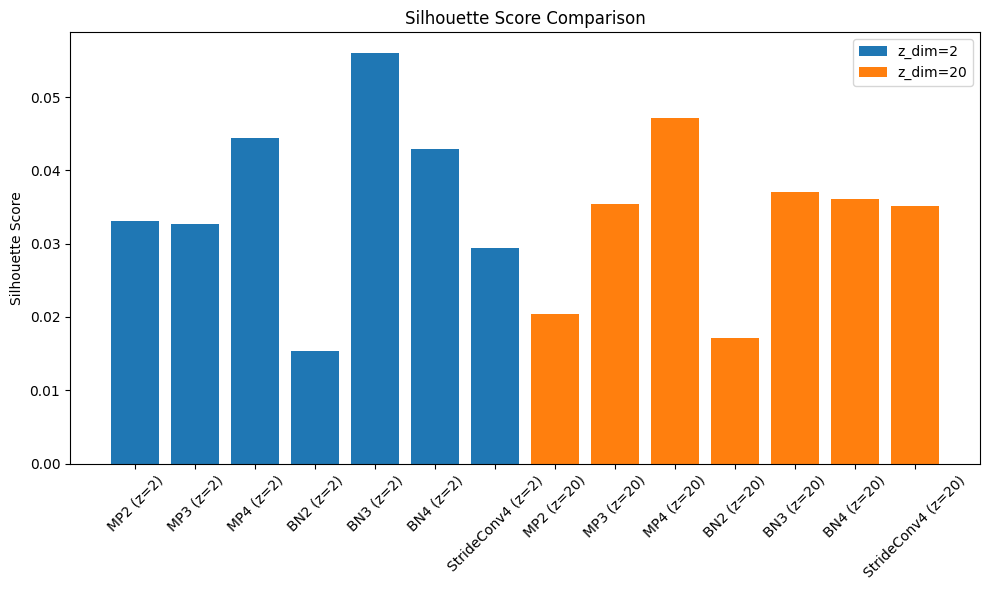

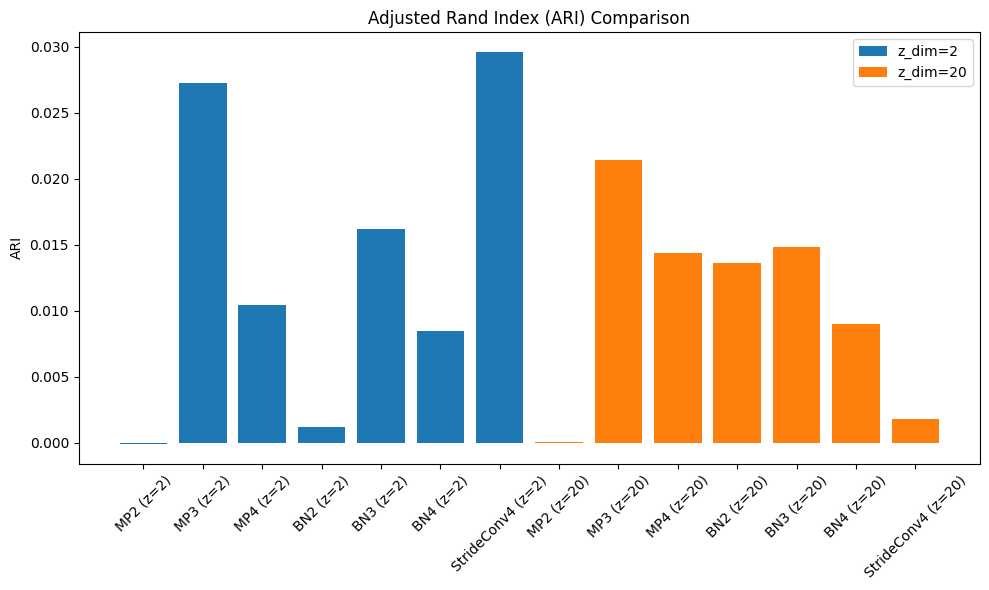

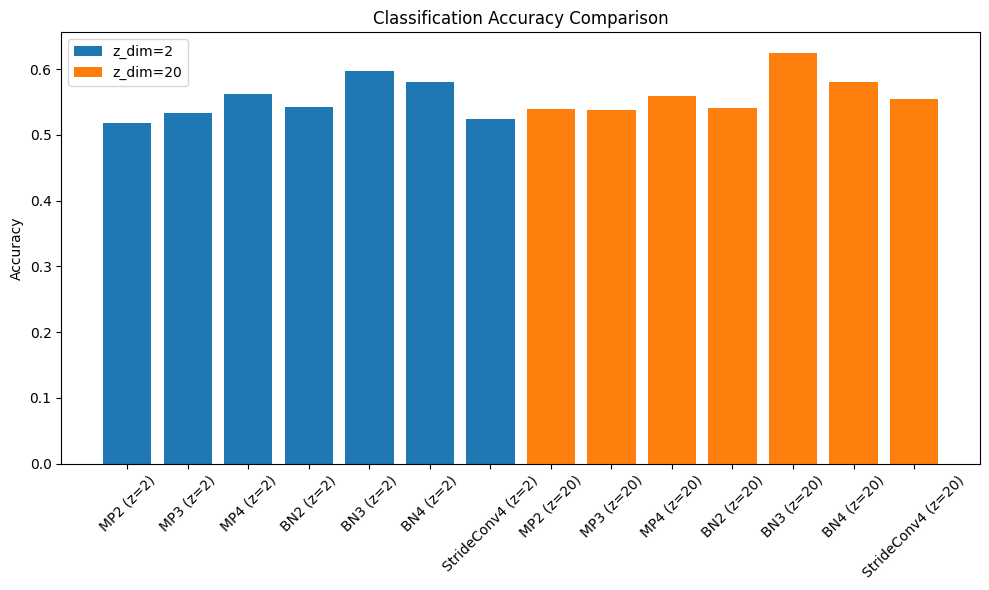

In [13]:
# After processing all models, convert the collected metrics to a DataFrame for later analysis.
df_metrics = pd.DataFrame(all_metrics)
print("Collected Metrics:")
print(df_metrics)

# -----------------------------------------
# Plotting the Metrics for Comparison
# -----------------------------------------
# Example: Plotting Silhouette Scores for each model and latent dimension.
plt.figure(figsize=(10, 6))
for dim in num_of_latent_features:
    subset = df_metrics[df_metrics["latent_dim"] == dim]
    plt.bar(subset["model"] + f" (z={dim})", subset["silhouette"], label=f"z_dim={dim}")
plt.title("Silhouette Score Comparison")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot Adjusted Rand Index (ARI)
plt.figure(figsize=(10, 6))
for dim in num_of_latent_features:
    subset = df_metrics[df_metrics["latent_dim"] == dim]
    plt.bar(subset["model"] + f" (z={dim})", subset["ARI"], label=f"z_dim={dim}")
plt.title("Adjusted Rand Index (ARI) Comparison")
plt.ylabel("ARI")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot Classification Accuracy
plt.figure(figsize=(10, 6))
for dim in num_of_latent_features:
    subset = df_metrics[df_metrics["latent_dim"] == dim]
    plt.bar(subset["model"] + f" (z={dim})", subset["accuracy"], label=f"z_dim={dim}")
plt.title("Classification Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()